In [1]:
# Environment setup and imports

# keep outputs clean by suppressing TensorFlow/CUDA warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF logging (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN warnings

# suppress CUDA registration warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# audio processing libraries
import librosa
import librosa.display

# deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import register_keras_serializable

# suppress additional TF warnings after import

tf.get_logger().setLevel('ERROR')

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility, arbitrary 42
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available: {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU config error: {e}")
else:
    print("No GPU detected - using CPU")


print("Completed setup")

2026-05-08 05:15:42.260282: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778217342.453534      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778217342.509895      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778217342.978858      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778217342.978899      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778217342.978902      57 computation_placer.cc:177] computation placer alr

GPU Available: /physical_device:GPU:0
GPU memory growth enabled
Completed setup


In [2]:
# download speecch commands dataset from kaggle

import kagglehub

path = kagglehub.dataset_download("yashdogra/speech-commands")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/yashdogra/speech-commands


In [3]:
# configure dataset for preprocessing

if os.path.exists(path):
    contents = os.listdir(path)
    print(f"Dataset found at: {path}")
    print(f"Total folders: {len(contents)}")
    print(f"Sample folders: {contents[:5]}...")
else:
    print(f"Dataset NOT found at: {path}")
    print("Please check your Kaggle dataset path")

# commands we are interested in
# for gaming example, we only use [up, down, left, right]
COMMANDS = [
    'yes', 'no', 'up', 'down', 'left', 'right',
    'on', 'off', 'stop', 'go'
]

# Audio parameters
SAMPLE_RATE = 16000      # 16kHz - the standard for speech
AUDIO_LENGTH = 16000     # 1 second of audio (16000 samples at 16kHz)
N_MELS = 128             # number of Mel frequency bands
N_FFT = 2048             # FFT window size
HOP_LENGTH = 160         # hop length between FFT windows

# Control dataset size
MAX_SAMPLES = None      # None for full dataset, or a number for faster testing

print(f"\nCommands to recognize: {COMMANDS}")
print(f"Number of classes: {len(COMMANDS)}")
print(f"\nMax samples per class: {'ALL (full dataset)' if MAX_SAMPLES is None else MAX_SAMPLES}")

Dataset found at: /kaggle/input/datasets/yashdogra/speech-commands
Total folders: 40
Sample folders: ['no', 'two', 'backward', 'four', 'five']...

Commands to recognize: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
Number of classes: 10

Max samples per class: ALL (full dataset)


# Preprocessing Pipeline

In [4]:
# Audio preprocessing functions

import glob

# load audio file and sample
def load_audio(file_path, target_sr=SAMPLE_RATE):
    # audio is time series numpy array
    audio, sr = librosa.load(file_path, sr=target_sr)
    return audio, sr


# pad or trim audio so all have same length
# needed for NN batch processing
def pad_or_trim(audio, target_length=AUDIO_LENGTH):
    if len(audio) < target_length:
        # pad zeros to the end
        padding = target_length - len(audio)
        audio = np.pad(audio, (0, padding), mode='constant') # mode = constant for zero padding
    else:
        # trim
        audio = audio[:target_length]
    return audio # fixed-length audio array


# standardize volume amplitude across audio files
# helps generalize across use environments
def normalize_audio(audio):
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio

# combine all the functions above for complete preprocessing pipeline
def preprocess_audio(file_path, target_sr=SAMPLE_RATE, target_length=AUDIO_LENGTH):

    audio, sr = load_audio(file_path, target_sr)
    audio = pad_or_trim(audio, target_length)
    audio = normalize_audio(audio)
    return audio      # final preprocessed audio

print("Audio preprocessing functions defined")

# Adding noise
# to prevent model from classifying quiet ambient noise as commands
NOISE_PATH = os.path.join(path, '_background_noise_')
NOISE_AUGMENT_PROB = 0.5    # 50% of data will have added noise
NOISE_SNR_DB = 10           # higher SNR -> quieter noise

# 1. load background noise files
def load_noise_files(noise_path, target_sr=SAMPLE_RATE):
    noise_clips = []
    for f in glob.glob(os.path.join(noise_path, '*.wav')):
        audio, _ = librosa.load(f, sr=target_sr)
        noise_clips.append(audio)
    print(f"Loaded {len(noise_clips)} noise files")
    return noise_clips

noise_clips = load_noise_files(NOISE_PATH)

# 2. slice noise recordings into 1s fragments. this is the silence class
def create_noise_samples(noise_clips, target_length=AUDIO_LENGTH, n_samples=1000):
    samples = []
    for _ in range(n_samples):
        clip = noise_clips[np.random.randint(len(noise_clips))]
        if len(clip) < target_length:
            clip = np.pad(clip, (0, target_length - len(clip)))
        start = np.random.randint(0, len(clip) - target_length)
        samples.append(clip[start:start + target_length])
    return samples

noise_samples = create_noise_samples(noise_clips, n_samples=1500)

# add '_background_noise_' class to dataset COMMANDS list, include these samples in X, y

# 3. mix random noise clip into audio at given SNR
def mix_noise(audio, noise_clips, snr_db=NOISE_SNR_DB):
    noise = noise_clips[np.random.randint(len(noise_clips))]

    # Grab a random window of the noise clip
    if len(noise) < len(audio):
        noise = np.pad(noise, (0, len(audio) - len(noise)))
    start = np.random.randint(0, len(noise) - len(audio) + 1)
    noise = noise[start:start + len(audio)]

    # Scale noise to desired SNR
    signal_power = np.mean(audio ** 2) + 1e-9
    noise_power  = np.mean(noise  ** 2) + 1e-9
    scale = np.sqrt(signal_power / (noise_power * (10 ** (snr_db / 10))))
    return normalize_audio(audio + scale * noise)

# 2D Mel spectrogram from audio
def extract_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS,
                            n_fft=N_FFT, hop_length=HOP_LENGTH):
    # Compute Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )
    # Convert to dB scale (log scale, better for neural networks)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

print(f"  Expected spectrogram shape: ({N_MELS}, {AUDIO_LENGTH // HOP_LENGTH + 1})")

Audio preprocessing functions defined
Loaded 6 noise files
  Expected spectrogram shape: (128, 101)


In [5]:
# SpecAugment: data augmentation for speech recognition
# directly augments spectrogram w/o adding data
# masks blocks of random frequency and time regions in spectrograms
# so model learns robust features w/o depending on single freq or time

# time warp not applied bc little effect and most expensive
"""
# train acc may be lower than val acc which is expected because masks are applied
to training but removed during validation
"""
# refer to https://arxiv.org/abs/1904.08779

class SpecAugment:

    # initialize SpecAugment with parameters
    def __init__(self, freq_mask_param=15, time_mask_param=20,
                 num_freq_masks=1, num_time_masks=1):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    # random frequency mask
    def frequency_mask(self, spec):
        num_mels = spec.shape[0]
        for _ in range(self.num_freq_masks):
            f = np.random.randint(0, self.freq_mask_param + 1)
            f = min(f, num_mels)
            f0 = np.random.randint(0, max(1, num_mels - f))
            spec[f0:f0 + f, :] = spec.mean()
        return spec

    # random time mask
    def time_mask(self, spec):
        num_frames = spec.shape[1]
        for _ in range(self.num_time_masks):
            t = np.random.randint(0, self.time_mask_param + 1)
            t = min(t, num_frames)
            t0 = np.random.randint(0, max(1, num_frames - t))
            spec[:, t0:t0 + t] = spec.mean()
        return spec

    # apply SpecAugment with given probability (0.5) of application
    def __call__(self, spec, augment_prob=0.5):
        if np.random.random() > augment_prob:
            return spec
        spec = spec.copy()
        spec = self.frequency_mask(spec)
        spec = self.time_mask(spec)
        return spec        # return augmented or og spectrogram


# initialize SpecAugment
spec_augment = SpecAugment(
    freq_mask_param=15,   # max frequency mask width
    time_mask_param=10,   # max time mask width
    num_freq_masks=1,     # number of frequency masks
    num_time_masks=1      # number of time masks
)

print(f"Frequency mask: up to {spec_augment.freq_mask_param} bands")
print(f"Time mask: up to {spec_augment.time_mask_param} frames")

Frequency mask: up to 15 bands
Time mask: up to 10 frames


In [6]:
# Create dataset from audio files

def create_dataset(dataset_path, commands, noise_samples=None, max_samples_per_class=None, verbose=True):
    X_raw = []
    X = []
    y = []

    print("LOADING DATASET")

    for command in commands:
        command_path = os.path.join(dataset_path, command)

        if not os.path.exists(command_path):
            print(f"Warning: Folder not found for '{command}'")
            continue

        # Get all .wav files
        files = [f for f in os.listdir(command_path) if f.endswith('.wav')]
        if max_samples_per_class:
            files = files[:max_samples_per_class]
        if verbose:
            print(f"  Processing '{command}': {len(files)} files")

        # Process each file
        for file_name in files:
            file_path = os.path.join(command_path, file_name)
            try:
                audio = preprocess_audio(file_path)         # preprocess audio
                features = extract_mel_spectrogram(audio)   # extract features
                X_raw.append(audio)     # save backup raw audio
                X.append(features)
                y.append(command)
            except Exception:           # skip problematic audio files
                continue

     # Add noise samples as background noise class
    if noise_samples is not None:
        print(f"  Processing '_background_noise_': {len(noise_samples)} samples")
        for audio in noise_samples:
            # apply same normalization and spectrogram extraction as commands
            audio = normalize_audio(audio)
            features = extract_mel_spectrogram(audio)
            X_raw.append(audio)
            X.append(features)
            y.append('_background_noise_')    # samples with noise


    X_raw = np.array(X_raw)
    X = np.array(X)
    y = np.array(y)

    print(f"Dataset created successfully!")
    print(f"Total samples: {len(X)}")
    print(f"Feature shape: {X.shape}")
    print(f"Classes: {len(np.unique(y))}")

    return X_raw, X, y


# Create dataset
NOISE_PATH = os.path.join(path, '_background_noise_')
noise_clips = load_noise_files(NOISE_PATH)
noise_samples = create_noise_samples(noise_clips, n_samples=1500)
X_raw, X, y = create_dataset(
    path,
    COMMANDS,
    noise_samples=noise_samples,
    max_samples_per_class=MAX_SAMPLES
)

Loaded 6 noise files
LOADING DATASET
  Processing 'yes': 4044 files
  Processing 'no': 3941 files
  Processing 'up': 3723 files
  Processing 'down': 3917 files
  Processing 'left': 3801 files
  Processing 'right': 3778 files
  Processing 'on': 3845 files
  Processing 'off': 3745 files
  Processing 'stop': 3872 files
  Processing 'go': 3880 files
  Processing '_background_noise_': 1500 samples
Dataset created successfully!
Total samples: 40046
Feature shape: (40046, 128, 101)
Classes: 11


In [7]:
# prepare data for training

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: '{label}'")

# Split spectrograms and raw waveforms with same random state
# 15% test, 85% train/validation
X_train, X_test, X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X, X_raw, y_encoded,
    test_size=0.15,
    random_state=42,      # keep data split consistent
    stratify=y_encoded    # balance classes in train and test sets
)

X_train, X_val, X_raw_train, X_raw_val, y_train, y_val = train_test_split(
    X_train, X_raw_train, y_train,
    test_size=0.12,
    random_state=42,
    stratify=y_train
)

print(f"\nDataset split:")
print(f"  Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Add channel dimension for CNN: (samples, height, width) -> (samples, height, width, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"\nInput shape for CNN: {X_train.shape[1:]}")

# Normalize using training statistics only (prevent data leakage)
# X_raw stays unnormalized — normalization happens per-sample in the generator
X_mean = np.mean(X_train)
X_std = np.std(X_train)

X_train = (X_train - X_mean) / X_std
X_val   = (X_val - X_mean) / X_std
X_test  = (X_test - X_mean) / X_std

print(f"Normalization stats: mean={X_mean:.4f}, std={X_std:.4f}")
print(f"Raw waveform splits: train={X_raw_train.shape}, val={X_raw_val.shape}, test={X_raw_test.shape}")

Label encoding:
  0: '_background_noise_'
  1: 'down'
  2: 'go'
  3: 'left'
  4: 'no'
  5: 'off'
  6: 'on'
  7: 'right'
  8: 'stop'
  9: 'up'
  10: 'yes'

Dataset split:
  Training:   29,954 samples (74.8%)
  Validation: 4,085 samples (10.2%)
  Test:       6,007 samples (15.0%)

Input shape for CNN: (128, 101, 1)
Normalization stats: mean=-56.7068, std=20.3224
Raw waveform splits: train=(29954, 16000), val=(4085, 16000), test=(6007, 16000)


In [8]:
# use cosine learning rate schedule with warmup for better convergence

@register_keras_serializable(package="CustomSchedules")
class CosineDecayWithWarmup(keras.optimizers.schedules.LearningRateSchedule):

#   1. Start with low LR to stabilize early training
#   2. Ramp up to peak LR during warmup
#   3. Smoothly decay to minimum LR using cosine curve

    # LR set parameters
    def __init__(self, initial_learning_rate=1e-3, decay_steps=10000,
                 warmup_steps=1000, min_learning_rate=1e-6):
        super().__init__()
        self.initial_learning_rate = initial_learning_rate
        self.decay_steps = decay_steps
        self.warmup_steps = warmup_steps
        self.min_learning_rate = min_learning_rate

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps_f = tf.cast(self.warmup_steps, tf.float32)
        decay_steps_f = tf.cast(self.decay_steps, tf.float32)

        # Linear warmup
        warmup_lr = self.initial_learning_rate * (step / tf.maximum(warmup_steps_f, 1.0))

        # Cosine decay
        decay_step = step - warmup_steps_f
        total_decay_steps = tf.maximum(decay_steps_f - warmup_steps_f, 1.0)
        cosine_decay = 0.5 * (1.0 + tf.cos(np.pi * decay_step / total_decay_steps))
        decayed_lr = self.min_learning_rate + \
                     (self.initial_learning_rate - self.min_learning_rate) * cosine_decay

        # Use warmup LR if in warmup phase, else use decayed LR
        return tf.where(step < warmup_steps_f, warmup_lr, decayed_lr)

    def get_config(self):
        return {
            'initial_learning_rate': float(self.initial_learning_rate),
            'decay_steps': int(self.decay_steps),
            'warmup_steps': int(self.warmup_steps),
            'min_learning_rate': float(self.min_learning_rate)
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)


print("CosineDecayWithWarmup learning rate schedule defined")

CosineDecayWithWarmup learning rate schedule defined


In [9]:
# data generator applying SpecAugment as we go
# each epoch has different augmented data -> better generalization
# does NOT augment validation/test data

class SpecAugmentDataGenerator(keras.utils.Sequence):
    def __init__(self, X_raw, y, batch_size=32, shuffle=True, augment=True,
                 spec_augment=None, noise_clips=None, noise_prob=0.5,
                 normalize_mean=0, normalize_std=1, augment_prob=0.5):
        self.X_raw = X_raw          # raw waveforms [N, AUDIO_LENGTH]
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.spec_augment = spec_augment or SpecAugment()
        self.noise_clips = noise_clips
        self.noise_prob = noise_prob
        self.mean = normalize_mean
        self.std  = normalize_std
        self.augment_prob = augment_prob
        self.indices = np.arange(len(X_raw))
        self.on_epoch_end()

    def __len__(self):
        # Number of batches per epoch
        return int(np.ceil(len(self.X_raw) / self.batch_size))

    def __getitem__(self, idx):
        # Get batch at index
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X = []

        for i in batch_idx:
            audio = self.X_raw[i].copy()

            # Mix in background noise before computing spectrogram
            if self.augment and self.noise_clips and np.random.random() < self.noise_prob:
                audio = mix_noise(audio, self.noise_clips)

            # Compute mel spectrogram
            spec = extract_mel_spectrogram(audio)

            # Apply SpecAugment to training data
            if self.augment:
                spec = self.spec_augment(spec, augment_prob=self.augment_prob)

            # Normalize + add channel dim
            spec = (spec - self.mean) / self.std
            batch_X.append(spec[..., np.newaxis])

        return np.array(batch_X), self.y[batch_idx]

    def on_epoch_end(self):
        # indices are shuffled after each epoch
        if self.shuffle:
            np.random.shuffle(self.indices)


# Create data generators
train_generator = SpecAugmentDataGenerator(
    X_raw_train, y_train,
    batch_size=32,
    shuffle=True,
    augment=True,  # apply SpecAugment
    spec_augment=spec_augment,
    noise_clips=noise_clips,
    noise_prob=0.5,
    normalize_mean=X_mean,
    normalize_std=X_std,
    augment_prob=0.5  # 50% chance to augment
)

val_generator = SpecAugmentDataGenerator(
    X_raw_val, y_val,
    batch_size=32,
    shuffle=False,
    augment=False,  # do not augment validation set
    normalize_mean=X_mean,
    normalize_std=X_std
)

print("Data generators created")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")
print(f"Batch size: 32")

Data generators created
Training batches: 937
Validation batches: 128
Batch size: 32


In [10]:
# ResNet-18 architecture

# residual block with skip connection: convolution, BN, ReLU
# skip connection allows gradients to flow directly through
def residual_block(x, filters, kernel_size=3, stride=1, use_projection=False):

    shortcut = x

    # 1st convolution
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 2nd convolution
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # project shortcut if dimensions don't match
    if use_projection or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=keras.regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # add skip connection and apply final activation
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

# Squeeze-and-Excitation weights feature channels by importance
def squeeze_excitation_block(x, ratio=16):

    channels = x.shape[-1]

    # squeeze using global average pooling
    se = layers.GlobalAveragePooling2D()(x)

    # excitation using 2 fully connected layers to generate weights
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)

    # scale channels by the learned weights
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

# ResNet model
def create_resnet_model(input_shape, num_classes):

    inputs = layers.Input(shape=input_shape)

    # Stem: initial convolution block: 7x7 + max pooling
    # capture broad patterns early on
    x = layers.Conv2D(32, 7, strides=2, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Residual stages with increasing filters and dropout
    # Stage 1: 64 filters
    # for low level features
    x = residual_block(x, 64, use_projection=True)
    x = residual_block(x, 64)
    x = layers.Dropout(0.1)(x)

    # Stage 2: 128 filters
    # low level features
    x = residual_block(x, 128, stride=2, use_projection=True)
    x = residual_block(x, 128)
    x = layers.Dropout(0.2)(x)

    # Stage 3: 256 filters + SE attention
    # for complex features
    x = residual_block(x, 256, stride=2, use_projection=True)
    x = residual_block(x, 256)
    x = squeeze_excitation_block(x)
    x = layers.Dropout(0.25)(x)

    # Stage 4: 512 filters + SE attention
    # for complex features
    x = residual_block(x, 512, stride=2, use_projection=True)
    x = residual_block(x, 512)
    x = squeeze_excitation_block(x)
    x = layers.Dropout(0.3)(x)

    # Classification head
    # global pooling, dense layers, regularization
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    # softmax probability for each command
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='CNN_ResNet18')


# create ResNet model
input_shape = X_train.shape[1:]
model = create_resnet_model(input_shape, num_classes)

# display summary of model
print("MODEL ARCHITECTURE")
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Model size: ~{model.count_params() * 4 / 1024 / 1024:.1f} MB")

I0000 00:00:1778218139.959904      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


MODEL ARCHITECTURE


Model: "CNN_ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 101,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 51,    │      1,600 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 51,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 51,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 26,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 26,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 26,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 26,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 26,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 26,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 26,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 26,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 26,    │          0 │ batch_normalizat

 Total params: 11,375,803 (43.40 MB)

 Trainable params: 11,365,371 (43.36 MB)

 Non-trainable params: 10,432 (40.75 KB)


Total parameters: 11,375,803
Model size: ~43.4 MB


  Epochs: 100
  Batch size: 32
  Steps per epoch: 937
  Total steps: 93,700
  Warmup steps: 4685 (5 epochs)
  Initial LR: 0.001
  Min LR: 1e-06


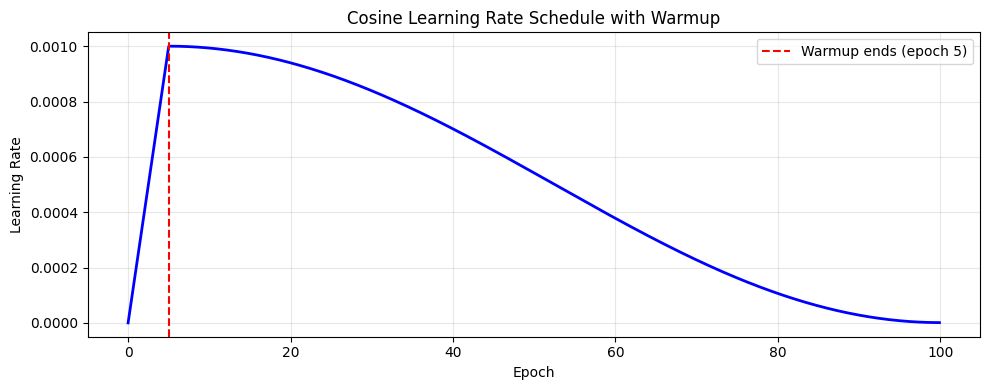


Model compiled with Adam optimizer and cosine LR schedule


In [11]:
# Training hyperparameters
EPOCHS = 100
BATCH_SIZE = 32
INITIAL_LR = 1e-3
MIN_LR = 1e-6
WARMUP_EPOCHS = 5

# calculate training steps
steps_per_epoch = len(train_generator)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps: {total_steps:,}")
print(f"  Warmup steps: {warmup_steps} ({WARMUP_EPOCHS} epochs)")
print(f"  Initial LR: {INITIAL_LR}")
print(f"  Min LR: {MIN_LR}")

# create LR schedule
lr_schedule = CosineDecayWithWarmup(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_steps,
    warmup_steps=warmup_steps,
    min_learning_rate=MIN_LR
)

# visualize LR schedule
steps = np.arange(0, total_steps, 100)
lrs = [float(lr_schedule(step)) for step in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps / steps_per_epoch, lrs, 'b-', linewidth=2)
plt.axvline(x=WARMUP_EPOCHS, color='r', linestyle='--', label=f'Warmup ends (epoch {WARMUP_EPOCHS})')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Cosine Learning Rate Schedule with Warmup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# compile model
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled with Adam optimizer and cosine LR schedule")

In [12]:
# training callback

callback_list = [
    # early stopping if there is no improvement in val acc
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),

    # model checkpoint: save model weights at new best val acc
    callbacks.ModelCheckpoint(
        filepath='best_model_resnet.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),

    # record training loss and acc to a csv
    callbacks.CSVLogger('training_log.csv', append=False)
]

print("Callbacks configured:")
print("- EarlyStopping (patience=15)")
print("- ModelCheckpoint (save best model)")
print("- CSVLogger (training_log.csv)")

Callbacks configured:
- EarlyStopping (patience=15)
- ModelCheckpoint (save best model)
- CSVLogger (training_log.csv)


In [ ]:
# train model

print(f"Model: ResNet-18 with SE attention")
print(f"Augmentation: SpecAugment")
print(f"LR Schedule: Cosine decay with {WARMUP_EPOCHS}-epoch warmup")
print("=" * 60)

# verbose=2 prevents IOPub rate limit error
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=2  # one line per epoch (prevents Kaggle output overflow)
)

print("Finished training")

Model: ResNet-18 with SE attention
Augmentation: SpecAugment
LR Schedule: Cosine decay with 5-epoch warmup
Epoch 1/100


I0000 00:00:1778218160.367703     116 service.cc:152] XLA service 0x7d79ac004b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778218160.367755     116 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778218163.588542     116 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778218178.193006     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_accuracy improved from -inf to 0.36548, saving model to best_model_resnet.keras
937/937 - 289s - 308ms/step - accuracy: 0.1577 - loss: 3.8498 - val_accuracy: 0.3655 - val_loss: 2.7673
Epoch 2/100

Epoch 2: val_accuracy improved from 0.36548 to 0.73929, saving model to best_model_resnet.keras
937/937 - 248s - 264ms/step - accuracy: 0.4561 - loss: 2.5864 - val_accuracy: 0.7393 - val_loss: 1.7837
Epoch 3/100

Epoch 3: val_accuracy improved from 0.73929 to 0.86879, saving model to best_model_resnet.keras
937/937 - 238s - 254ms/step - accuracy: 0.7444 - loss: 1.7712 - val_accuracy: 0.8688 - val_loss: 1.3963
Epoch 4/100

Epoch 4: val_accuracy did not improve from 0.86879
937/937 - 234s - 249ms/step - accuracy: 0.8035 - loss: 1.5879 - val_accuracy: 0.8245 - val_loss: 1.5542
Epoch 5/100

Epoch 5: val_accuracy improved from 0.86879 to 0.88519, saving model to best_model_resnet.keras
937/937 - 261s - 279ms/step - accuracy: 0.8348 - loss: 1.4741 - val_accuracy: 0.8852 - val_loss: 1.

# Model Performace Analysis

In [ ]:
# Plots of accuracy and loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy plot
axes[0].plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# loss plot
axes[1].plot(history.history['loss'], 'b-', label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# training summary
best_val_acc = max(history.history['val_accuracy'])
best_epoch = np.argmax(history.history['val_accuracy']) + 1
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Total epochs: {len(history.history['accuracy'])}")
print(f"Best val acc: {best_val_acc:.4} (epoch {best_epoch})")
print(f"Final train acc: {final_train_acc:.4f}")
print(f"Final val acc: {final_val_acc:.4f}")

In [ ]:
# evaluate on test set

# load best model with custom objects
custom_objects = {'CosineDecayWithWarmup': CosineDecayWithWarmup}
best_model = keras.models.load_model('best_model_resnet.keras',
                                      custom_objects=custom_objects)

# evaluate on test set
print("Evaluating on test set...")
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# generate predictions
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# classification report
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))
# support: number of occurrences of each clas
# macro avg: unweighted mean of metric
# weighted mean: mean of metric weighted by support of each class

In [ ]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("Per-Class Accuracy:")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for name, acc in sorted(zip(label_encoder.classes_, class_accuracy), key=lambda x: -x[1]):
    bar = '█' * int(acc * 30)
    print(f"  {name:8s}: {acc:.4f} {bar}")

In [ ]:
# save model and configuaration

import json
import pickle

# Save final model
model.save('voice_command_model_final_noise.keras')
print("Model saved: voice_command_model_final_noise.keras")

# Save label encoder
with open('label_encoder_noise.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("Label encoder saved: label_encoder_noise.pkl")

# Save configuration
config = {
    'model_name': 'CNN_Transformer_Audio',
    'commands': list(label_encoder.classes_),
    'num_classes': num_classes,
    'sample_rate': SAMPLE_RATE,
    'audio_length': AUDIO_LENGTH,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'feature_mean': float(X_mean),
    'feature_std': float(X_std),
    'test_accuracy': float(test_accuracy),
    'best_val_accuracy': float(best_val_acc),
    'training_epochs': len(history.history['accuracy']),
    'noise_augmentation': True,
    'noise_prob': NOISE_AUGMENT_PROB,
    'noise_snr_db': NOISE_SNR_DB,
    'noise_class_samples': len(noise_samples),
}

with open('model_config_noise.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Config saved: model_config_noise.json")

# Print config
print("\nModel Configuration:")
print(json.dumps(config, indent=2))

print(f"\nFinal Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\nFiles saved:")
print("- best_model_resnet.keras (best checkpoint)")
print("- voice_command_model_final_noise.keras (final model)")
print("- label_encoder_noise.pkl (label mapping)")
print("- model_config_noise.json (configuration)")
print("- training_log.csv (training history)")